3, 13) Datasetet “hr_employee_data.xlsx” innehåller data kopplat till ett företags anställda. 
Gör en EDA och tillhörande analys, föreställ dig att ledningsgruppen på ett företag ska ta del av analysen. 
I denna uppgift ska ingen ML-modellering göras (det kommer göras i nästa kapitel).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
df = pd.read_excel("hr_employee_data.xlsx")
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
# Emp_Id, Department och salary columnerna har datatypen objekt, och det finns inga saknade värden i datasetet.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  object 
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  object 
 10  salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 1.3+ MB


In [ ]:
# Här kan vi också se att det finns inga null värden i datasetet.
df.isnull().sum()

Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [5]:
# Här kan vi se översiktliga statistiska mått.
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [6]:
# Tre columner har datatypen object, vilket innebär att de innehåller textdata.
df.select_dtypes(include="object").columns

Index(['Emp_Id', 'Department', 'salary'], dtype='object')

In [7]:
# Nu vill jag se hur många variabler som finns i "Department" columnen och hur många anställda som finns i varje avdelning.
# En stor del av de anställda jobbar i "sales" avdelningen, följt av "technical" och "support".
df["Department"].value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [8]:
# Samma för "salary" column. Vi kan se at det finns tre olika lönenivåer, och att det är flest anställda som har "low" lön.
df["salary"].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [ ]:
# Jag vill se om det finns dubblicerade ID, och det finns inte (False).
df["Emp_Id"].duplicated().any()

np.False_

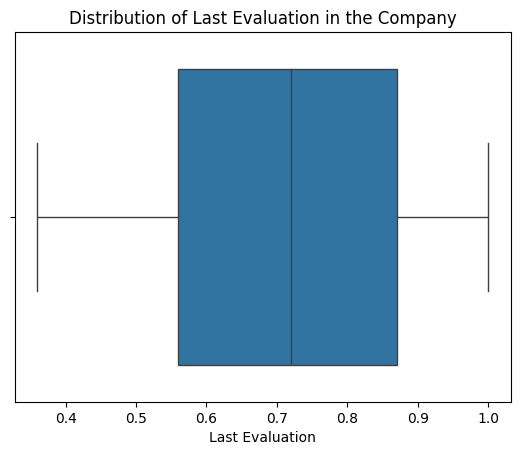

In [10]:
# Box plot för att se fördelningen av "last_evaluation" vilket jag tolkade som satisfaction level som undersökades för flera år sedan.

sns.boxplot(x=df["last_evaluation"])

plt.title("Distribution of Last Evaluation in the Company")
plt.xlabel("Last Evaluation")
plt.show()

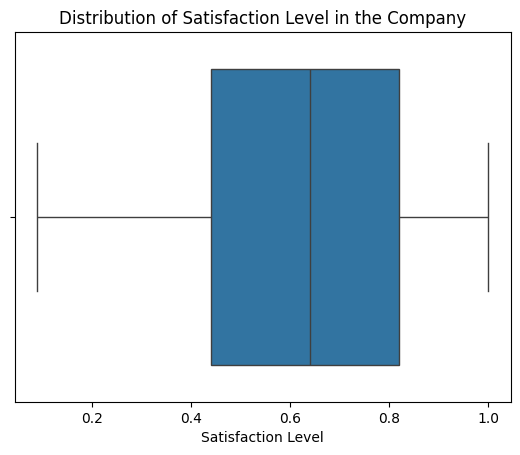

In [11]:
# Box plot för att se fördelningen av "satisfaction_level" vilket jag tolkade som satisfaction level som undersökades nyligen.
# Om man ser båda diagrammen kan det vara lite missvisande först, men "Distribution of Last Evaluation in the Company" har en mindre spridning än detta.
# Generellt sett minskade Satisfaction Level i företaget, vilket kan vara en anledning till att många anställda har slutat.

sns.boxplot(x=df["satisfaction_level"])

plt.title("Distribution of Satisfaction Level in the Company")
plt.xlabel("Satisfaction Level")
plt.show()

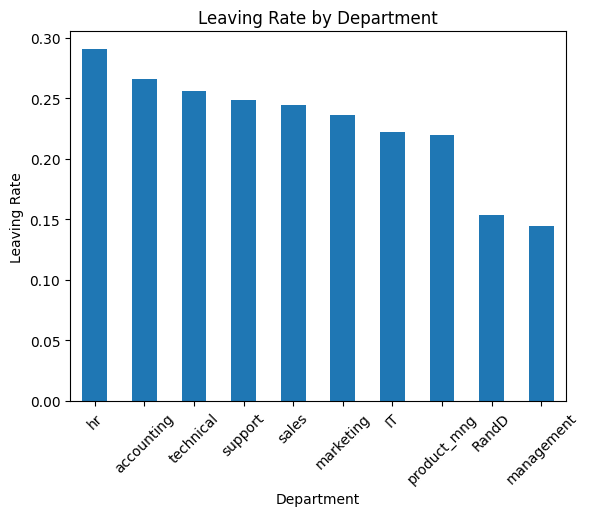

In [12]:
# Bar plot för att se "leaving rate" i varje avdelning.
# Jag menar "leaving rate" som antalet anställda som har lämnat företaget delat med det totala antalet anställda i varje avdelning.

leaving_rate = df.groupby("Department")["left"].mean().sort_values(ascending=False)
leaving_rate.plot(kind="bar")

plt.title("Leaving Rate by Department")
plt.xlabel("Department")
plt.ylabel("Leaving Rate")
plt.xticks(rotation=45)
plt.show()

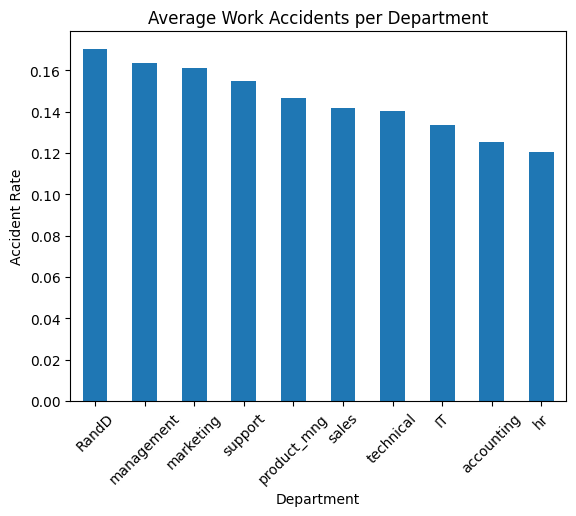

In [13]:
# Här kan man se att "RandD" avdelningen har den högsta Work Accidents, följt av "management" och "marketing".
# Det verkar inte finnas en tydlig koppling mellan "Leaving Rate" och "Work_accident".

accident_rate = df.groupby("Department")["Work_accident"].mean().sort_values(ascending=False)

plt.figure()
accident_rate.plot(kind="bar")

plt.title("Average Work Accidents per Department")
plt.ylabel("Accident Rate")
plt.xlabel("Department")

plt.xticks(rotation=45)
plt.show()